# Main Relationship Analysis
## Task 3: Analyzing the relationship between Sleep/Study Hours and Academic Performance (GPA)

**Objective:** Explore and visualize how sleep hours and study hours affect student GPA

In [53]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### Libraries Used

| Library | Purpose |
|---------|---------|
| `pandas` | Load and manipulate the dataset |
| `numpy` | Numerical operations for regression line points |
| `matplotlib` / `seaborn` | Plotting and visualization |
| `scipy.stats` | `linregress` for linear regression and significance testing |

In [ ]:
# Load the cleaned dataset
df = pd.read_csv('../../data/processed/student_lifestyle_cleaned.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset Shape: (2000, 7)

First few rows:


,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,8.1,0.6,6.5,2.2,6.6,3.51,High


### Dataset

2,000 student records with 7 columns. This analysis focuses on three: `Sleep_Hours_Per_Day`, `Study_Hours_Per_Day`, and `GPA` (the target variable).

In [55]:
# Display summary statistics
print("Summary Statistics:")
df[["Sleep_Hours_Per_Day", "Study_Hours_Per_Day", "GPA"]].describe()

Summary Statistics:


,Sleep_Hours_Per_Day,Study_Hours_Per_Day,GPA
count,2000.000000,2000.000000,2000.000000
mean,7.501250,7.475800,3.115960
std,1.460949,1.423888,0.298674
min,5.000000,5.000000,2.240000
25%,6.200000,6.300000,2.900000
50%,7.500000,7.400000,3.110000
75%,8.800000,8.700000,3.330000
max,10.000000,10.000000,4.000000


### Summary Statistics

- Sleep and study hours both average ~7.5 hrs/day with similar spreads.
- GPA mean is 3.12 (std 0.30) — most students fall in the B–B+ range.
- No missing values across all 2,000 records.

---
## 1. Sleep Hours vs GPA Analysis

### Statistical Methods

- **Correlation (r)** — strength and direction of the linear relationship, from -1 to +1. Values near 0 mean no linear relationship.
- **R²** — proportion of GPA variance explained by the predictor (0 = none, 1 = perfect).
- **p-value** — probability the result occurred by chance. Below 0.05 = statistically significant.

In [56]:
# Calculate correlation coefficient
sleep_gpa_corr = df['Sleep_Hours_Per_Day'].corr(df['GPA'])

# Perform linear regression
slope_sleep, intercept_sleep, r_value_sleep, p_value_sleep, std_err_sleep = stats.linregress(
    df['Sleep_Hours_Per_Day'], df['GPA']
)

print(f"Correlation between Sleep Hours and GPA: {sleep_gpa_corr:.4f}")
print(f"Linear Regression Equation: GPA = {slope_sleep:.4f} Ã— Sleep_Hours + {intercept_sleep:.4f}")
print(f"R-squared: {r_value_sleep**2:.4f}")
print(f"P-value: {p_value_sleep:.6f}")

Correlation between Sleep Hours and GPA: -0.0043
Linear Regression Equation: GPA = -0.0009 Ã— Sleep_Hours + 3.1225
R-squared: 0.0000
P-value: 0.848354


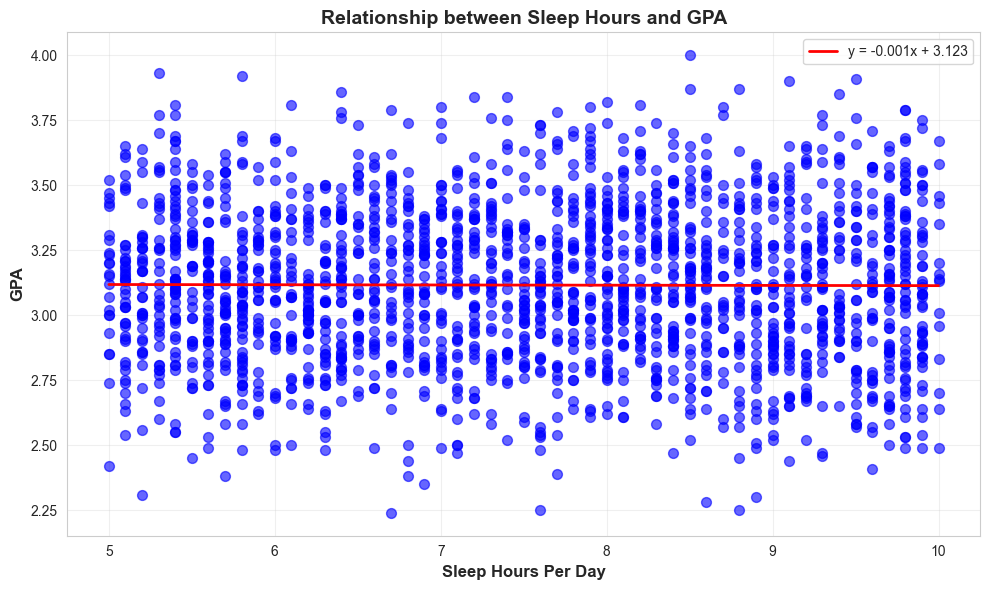


Correlation Coefficient: -0.0043


In [57]:
# Create scatter plot for Sleep Hours vs GPA
plt.figure(figsize=(10, 6))
plt.scatter(df['Sleep_Hours_Per_Day'], df['GPA'], alpha=0.6, color='blue', s=50)

# Add regression line
x_line = np.array([df['Sleep_Hours_Per_Day'].min(), df['Sleep_Hours_Per_Day'].max()])
y_line = slope_sleep * x_line + intercept_sleep
plt.plot(x_line, y_line, color='red', linewidth=2, label=f'y = {slope_sleep:.3f}x + {intercept_sleep:.3f}')

plt.xlabel('Sleep Hours Per Day', fontsize=12, fontweight='bold')
plt.ylabel('GPA', fontsize=12, fontweight='bold')
plt.title('Relationship between Sleep Hours and GPA', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nCorrelation Coefficient: {sleep_gpa_corr:.4f}")

### Results: Sleep Hours vs GPA

- r = **-0.0043** — essentially no relationship
- GPA = -0.0009 × Sleep_Hours + 3.1225
- R² = **0.000018** — sleep hours explain < 0.002% of GPA variance
- p = **0.848** — not statistically significant

Sleep hours have **no meaningful linear relationship with GPA** in this dataset.

---
## 2. Study Hours vs GPA Analysis

We apply the same approach to study hours to see whether time invested in studying is a stronger predictor of GPA than sleep.

In [58]:
# Calculate correlation coefficient
study_gpa_corr = df['Study_Hours_Per_Day'].corr(df['GPA'])

# Perform linear regression
slope_study, intercept_study, r_value_study, p_value_study, std_err_study = stats.linregress(
    df['Study_Hours_Per_Day'], df['GPA']
)

print(f"Correlation between Study Hours and GPA: {study_gpa_corr:.4f}")
print(f"Linear Regression Equation: GPA = {slope_study:.4f} Ã— Study_Hours + {intercept_study:.4f}")
print(f"R-squared: {r_value_study**2:.4f}")
print(f"P-value: {p_value_study:.6f}")

Correlation between Study Hours and GPA: 0.7345
Linear Regression Equation: GPA = 0.1541 Ã— Study_Hours + 1.9642
R-squared: 0.5394
P-value: 0.000000


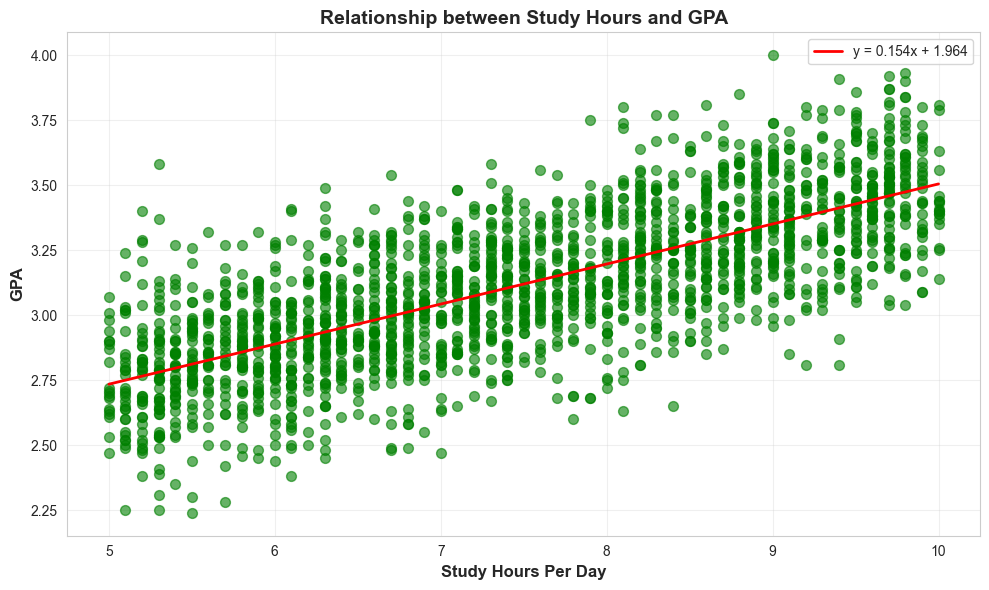


Correlation Coefficient: 0.7345


In [59]:
# Create scatter plot for Study Hours vs GPA
plt.figure(figsize=(10, 6))
plt.scatter(df['Study_Hours_Per_Day'], df['GPA'], alpha=0.6, color='green', s=50)

# Add regression line
x_line = np.array([df['Study_Hours_Per_Day'].min(), df['Study_Hours_Per_Day'].max()])
y_line = slope_study * x_line + intercept_study
plt.plot(x_line, y_line, color='red', linewidth=2, label=f'y = {slope_study:.3f}x + {intercept_study:.3f}')

plt.xlabel('Study Hours Per Day', fontsize=12, fontweight='bold')
plt.ylabel('GPA', fontsize=12, fontweight='bold')
plt.title('Relationship between Study Hours and GPA', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nCorrelation Coefficient: {study_gpa_corr:.4f}")

### Results: Study Hours vs GPA

- r = **0.7345** — strong positive relationship
- GPA = 0.1541 × Study_Hours + 1.9642
- R² = **0.5394** — study hours explain **54%** of GPA variance
- p ≈ **0.000** — highly statistically significant

Each additional study hour is associated with a **+0.154 GPA increase**. Study hours are a strong, reliable predictor of academic performance.

---
## 3. Comparative Analysis

Both relationships are plotted side by side to make the contrast immediately visible — one trend line is nearly flat (sleep) while the other rises steeply (study).

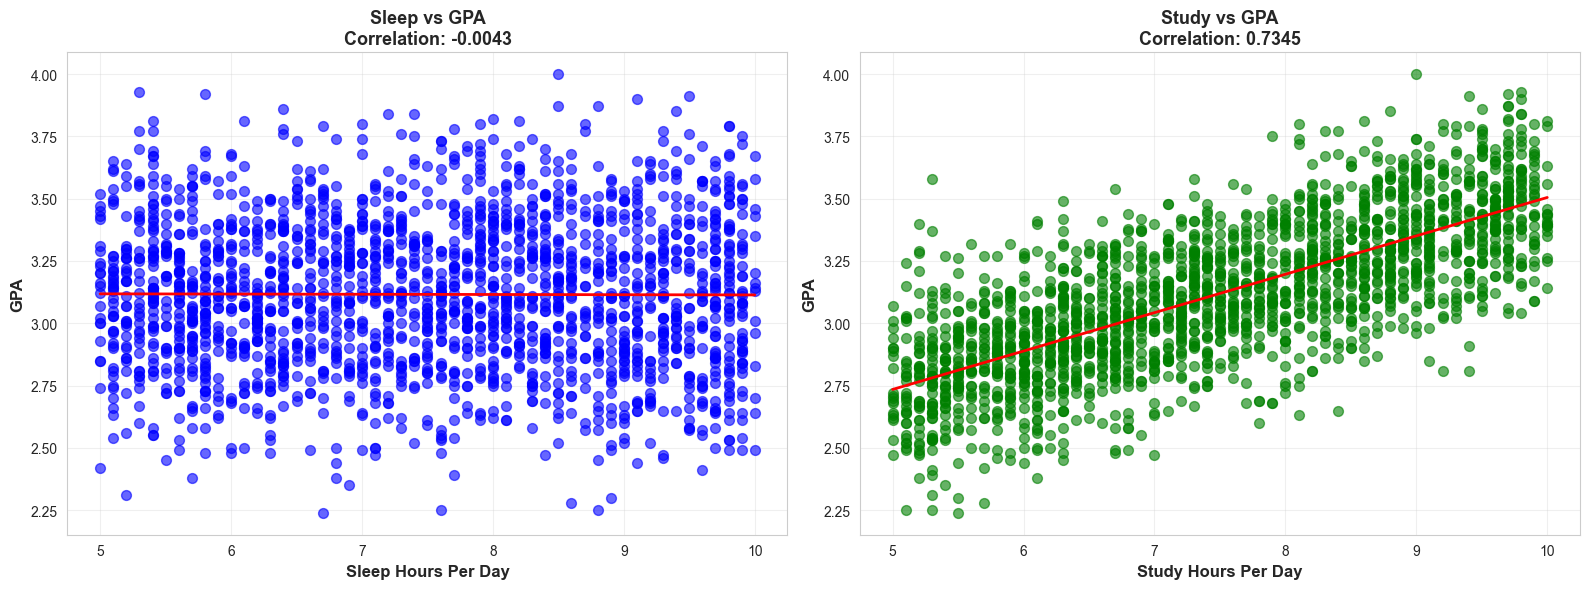

In [60]:
# Create side by side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sleep Hours vs GPA
axes[0].scatter(df['Sleep_Hours_Per_Day'], df['GPA'], alpha=0.6, color='blue', s=50)
x_line = np.linspace(df['Sleep_Hours_Per_Day'].min(), df['Sleep_Hours_Per_Day'].max(), 100)
y_line = slope_sleep * x_line + intercept_sleep
axes[0].plot(x_line, y_line, color='red', linewidth=2)
axes[0].set_xlabel('Sleep Hours Per Day', fontsize=12, fontweight='bold')
axes[0].set_ylabel('GPA', fontsize=12, fontweight='bold')
axes[0].set_title(f'Sleep vs GPA\nCorrelation: {sleep_gpa_corr:.4f}', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Study Hours vs GPA
axes[1].scatter(df['Study_Hours_Per_Day'], df['GPA'], alpha=0.6, color='green', s=50)
x_line = np.linspace(df['Study_Hours_Per_Day'].min(), df['Study_Hours_Per_Day'].max(), 100)
y_line = slope_study * x_line + intercept_study
axes[1].plot(x_line, y_line, color='red', linewidth=2)
axes[1].set_xlabel('Study Hours Per Day', fontsize=12, fontweight='bold')
axes[1].set_ylabel('GPA', fontsize=12, fontweight='bold')
axes[1].set_title(f'Study vs GPA\nCorrelation: {study_gpa_corr:.4f}', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [61]:
# Summary comparison table
comparison_data = {
    'Factor': ['Sleep Hours', 'Study Hours'],
    'Correlation with GPA': [sleep_gpa_corr, study_gpa_corr],
    'Slope': [slope_sleep, slope_study],
    'R-squared': [r_value_sleep**2, r_value_study**2],
    'P-value': [p_value_sleep, p_value_study]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*70)
print("COMPARATIVE SUMMARY: SLEEP HOURS vs STUDY HOURS")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)


COMPARATIVE SUMMARY: SLEEP HOURS vs STUDY HOURS
     Factor  Correlation with GPA     Slope  R-squared  P-value
Sleep Hours             -0.004278 -0.000875   0.000018 0.848354
Study Hours              0.734468  0.154061   0.539443 0.000000


### Reading the Comparison Table

| Factor | r | Slope | R² | p-value |
|--------|---|-------|----|----------|
| Sleep Hours | -0.004 | -0.0009 | ~0 | 0.848 |
| Study Hours | +0.735 | +0.154 | 0.539 | ~0.000 |

Study hours dominate on every metric. Sleep hours show no statistically significant relationship with GPA.

### Conclusions

1. **Study hours are the dominant predictor** (r = 0.73, R² = 0.54, p ≈ 0) — students who study more consistently earn higher GPAs.
2. **Sleep hours show no significant relationship** (r = -0.004, p = 0.85) — sleep quantity alone does not predict GPA in this dataset.
3. **Correlation ≠ causation** — unmeasured factors (motivation, study quality, stress) likely drive both variables.
4. **Next step:** A multivariate model including all lifestyle variables would reveal whether sleep has an indirect effect once study hours and stress are controlled for.

In [62]:
# Save key findings
print("\n" + "="*70)
print("KEY FINDINGS SUMMARY")
print("="*70)
print(f"\n1. Sleep Hours vs GPA:")
print(f"   - Correlation: {sleep_gpa_corr:.4f}")
print(f"   - Formula: GPA = {slope_sleep:.4f} Ã— Sleep_Hours + {intercept_sleep:.4f}")
print(f"   - Interpretation: Each additional hour of sleep is associated with "
      f"a {abs(slope_sleep):.4f} {'increase' if slope_sleep > 0 else 'decrease'} in GPA")

print(f"\n2. Study Hours vs GPA:")
print(f"   - Correlation: {study_gpa_corr:.4f}")
print(f"   - Formula: GPA = {slope_study:.4f} Ã— Study_Hours + {intercept_study:.4f}")
print(f"   - Interpretation: Each additional hour of study is associated with "
      f"a {abs(slope_study):.4f} {'increase' if slope_study > 0 else 'decrease'} in GPA")

# Determine which factor is more strongly associated
if abs(sleep_gpa_corr) > abs(study_gpa_corr):
    stronger = "Sleep Hours"
    weaker = "Study Hours"
else:
    stronger = "Study Hours"
    weaker = "Sleep Hours"

print(f"\n3. Comparative Finding:")
print(f"   - {stronger} shows a stronger correlation with GPA than {weaker}")
print(f"   - However, both factors contribute to academic performance")
print("\n" + "="*70)


KEY FINDINGS SUMMARY

1. Sleep Hours vs GPA:
   - Correlation: -0.0043
   - Formula: GPA = -0.0009 Ã— Sleep_Hours + 3.1225
   - Interpretation: Each additional hour of sleep is associated with a 0.0009 decrease in GPA

2. Study Hours vs GPA:
   - Correlation: 0.7345
   - Formula: GPA = 0.1541 Ã— Study_Hours + 1.9642
   - Interpretation: Each additional hour of study is associated with a 0.1541 increase in GPA

3. Comparative Finding:
   - Study Hours shows a stronger correlation with GPA than Sleep Hours
   - However, both factors contribute to academic performance

